In [336]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import statsmodels.api as sm
import scipy.stats as stats
from bokeh.plotting import figure, show, output_file, output_notebook, ColumnDataSource

In [337]:
retail_data = "C:/Users/Killi/OneDrive/Programming For Data Analytics/Jupyter/Datasets/retail_store_sales_cleaned.csv"
data = pd.read_csv(retail_data)
data.head()

,transaction_id,customer_id,category,item,price_per_unit,quantity,total_spent,payment_method,location,transaction_date,day_of_week,is_weekend
0,TXN_2070726,CUST_22,Milk Products,Item_6_MILK,12.5,5.0,62.5,Digital Wallet,In-Store,2022-01-01,Saturday,True
1,TXN_1519499,CUST_15,Computers And Electric Accessories,Item_6_CEA,12.5,6.0,75.0,Credit Card,Online,2022-01-01,Saturday,True
2,TXN_9364474,CUST_19,Food,Item_22_FOOD,36.5,3.0,109.5,Cash,In-Store,2022-01-01,Saturday,True
3,TXN_6950467,CUST_01,Computers And Electric Accessories,Item_6_CEA,12.5,6.0,75.0,Digital Wallet,In-Store,2022-01-01,Saturday,True
4,TXN_6329331,CUST_24,Beverages,Item_8_BEV,15.5,5.0,77.5,Credit Card,Online,2022-01-01,Saturday,True


In [338]:
# Descriptive statistics for all numeric variables
numeric_summary = data.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
price_per_unit,12575.0,23.365912,10.480118,5.0,14.000000,23.365912,32.0,41.0
quantity,12575.0,5.536380,2.788398,1.0,3.000000,5.536380,8.0,10.0
total_spent,12575.0,129.689385,92.165610,5.0,52.595606,110.727592,190.0,410.0


This table summarises the numerical variables in the dataset and measures of central tendency and spread.
For each variable we get:

mean (average value)

standard deviation (how spread out the data are)

minimum and maximum

25th, 50th (median) and 75th percentiles

These statistics show transaction values, quantities purchased, and unit prices. The median values allow us to compare central tendency without the influence of skew. The mean and standard deviation show average behaviour and variation.

In [339]:
from scipy import stats 
# Mode for numeric variables
numeric_mode = data.select_dtypes(include=['float64','int64']).mode().T
print("Numeric variable modes:\n", numeric_mode)


Numeric variable modes:
                    0
price_per_unit  33.5
quantity        10.0
total_spent     40.0


The mode() function finds the most frequently found values in the dataset.
For numeric columns this shows common transaction amounts or unit prices.

These mode values is a third measure of central tendency helping the mean and median.

In [340]:
data.select_dtypes(include=['object', 'category']).describe().T


,count,unique,top,freq
transaction_id,12575,12575,TXN_2070726,1
customer_id,12575,25,CUST_05,544
category,12575,8,Furniture,1591
item,12575,201,Missing,1213
payment_method,12575,3,Cash,4310
location,12575,2,Online,6354
transaction_date,12575,1114,2022-05-30,26
day_of_week,12575,7,Wednesday,1813


This summary gives counts and the number of unique categories for each categorical variable.

These values describe customer behaviour like which product categories or payment methods dominate the dataset.

In [341]:
# Pearson correlation between numeric variables
correlation_matrix = data.corr(numeric_only=True)
correlation_matrix


,price_per_unit,quantity,total_spent,is_weekend
price_per_unit,1.000000,0.011185,0.632389,-0.002290
quantity,0.011185,1.000000,0.714478,0.010432
total_spent,0.632389,0.714478,1.000000,0.006321
is_weekend,-0.002290,0.010432,0.006321,1.000000


The Pearson correlation matrix finds linear relationships between the numerical variables such as price_per_unit, quantity, and total_spent.
Correlation values range from -1 to +1:

+1: strong positive linear relationship

0: no linear relationship

–1: strong negative linear relationship

These correlations show how strongly each predictor is related to transaction value and help find which variables should be included in modelling.

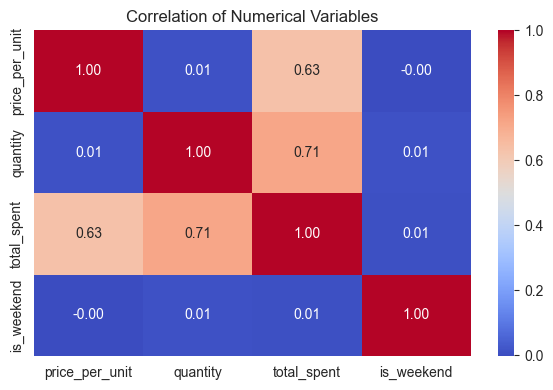

In [342]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Numerical Variables")
plt.tight_layout()
plt.show()


# Correlation heatmap and matrix 
This is a correlation matrix of all numerical variables in the dataset. Correlation analysis helps identify linear relationships between continuous variables and can find multicollinearity issues.

A correlation heatmap gives a view of how numerical variables move together. Variables with high correlation can need removal or transformation.

 
The correlation matrix is computed using Pearsons correlation coefficient which measures the strength and direction of a linear relationship between two continuous variables.  
The color palette is used to identify positive and negative linear relationships.  
The annot=True argument adds numbers to each cell.  

This exploratory step helps find potential redundant features and variables that can add multicollinearity into regression models.

Strong correlations are darker colours allowing meaningful patterns such as strong relationships between quantity and total spend to become clear.

# Overview of the Dataset

The dataset contains retail transaction records collected from a store. Each row represents a single customer transaction and the dataset includes variables describing the products purchased, the transaction value, the payment method used and the date on which the purchase occurred. After cleaning the dataset consists of 12,575 observations and a mixture of numerical, categorical and date-based variables.

# Variables of Interest

The key variables include:

total_spent – the final amount paid in each transaction (numeric).

price_per_unit – the unit price of the item(s) purchased (numeric).

quantity – the number of items purchased in the transaction (numeric).

category – the type of product purchased (categorical).

payment_method – method used to pay for the transaction (categorical).

transaction_date – the date of the transaction (datetime).

day_of_week – derived variable indicating the weekday name (categorical).

is_weekend – Boolean indicator identifying weekend purchases (categorical/binary).

These variables are used in the analysis to compare spending patterns, examine differences between groups and explore relationships between variables.

# Identification of Missing Data

 Missing values existed in several columns. Some were actual gaps while others were nonsense values such as "?", "missing", "NaN" or "error". These were found using isin() and then converted into proper NaN values.

The Item column contained missing values because certain transactions did not have proper product names. These were replaced with "Missing" and did not affect the analysis.
The Discount Applied column contained many missing values which could have been unrecorded (non-discounted) transactions. Because this variable was not central to the analysis and had alot of missingness it was removed.

# Identification and Treatment of Outliers

Outliers in the numerical variables (price_per_unit, quantity and total_spent) were identified using the Interquartile Range (IQR) method. Extreme values outside 1.5 × IQR were flagged. Instead of removing entire rows these outliers were replaced with NaN using .mask() and imputed using the column means. This approach allowed for maintaining the size and structure of the dataset.

# Final Dataset Quality

After all cleaning steps:

No numerical column contains missing or non-numeric values.

No column contains nonsense values.

All categorical variables are consistently formatted.

Dates are parsed correctly and time-based variables are generated.

Outliers are treated appropriately without affecting the dataset.

The final dataset is tidy, consistent and ready for analysis

# Univariate Visualisations

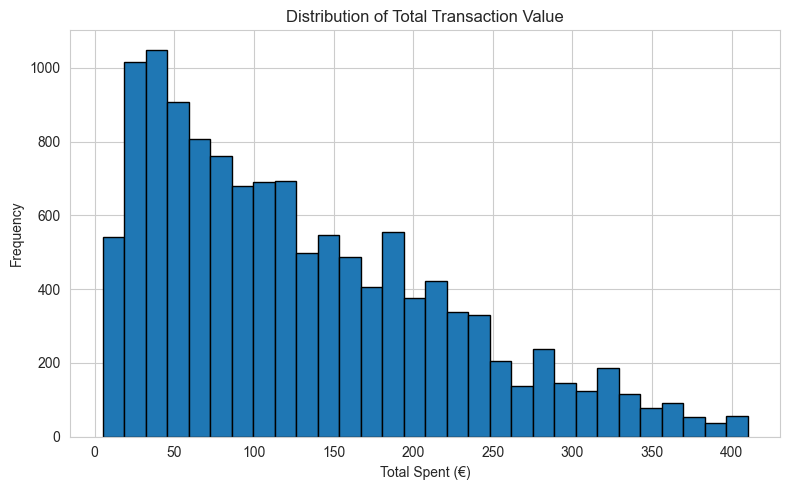

In [343]:
#Histogram of total transaction value

plt.figure(figsize=(8,5))
plt.hist(data['total_spent'], bins=30, edgecolor='black')
plt.title("Distribution of Total Transaction Value")
plt.xlabel("Total Spent (€)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Histogram showing Distribution of Total Transaction Value
The distribution shape provides insights into central tendency, variability and skewness. 

Histograms are used to find extreme outliers, heavy tails and skewness these are all useful when checking assumptions and trying to decide what statistical method to use.

This histogram displays the distribution of total transaction values. The distribution is right-skewed which is common in retail settings where most customers spend less while fewer make higher-value purchases. The presence of a long tail indicates occasional large transactions. Understanding this skew is important for selecting statistical methods and interpreting mean values.

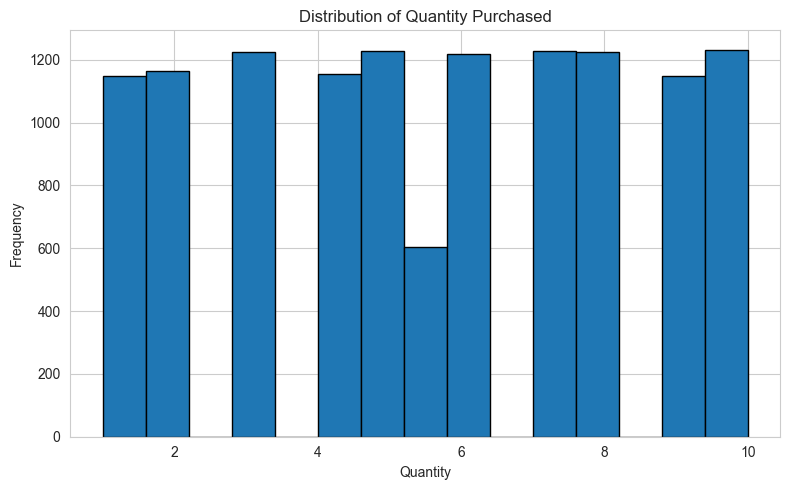

In [344]:
#Histogram of Quantity purchased
plt.figure(figsize=(8,5))
plt.hist(data['quantity'], bins=15, edgecolor='black')
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Most transactions involve only a small number of items with the distribution mostly around low quantities. Typical retail transactions involve only one or two items. Occasional purchases of higher quantities are rare.

Total Revenue per Month:
year_month
2022-01-01    55658.206889
2022-02-01    45556.853420
2022-03-01    42935.990279
2022-04-01    42355.564981
2022-05-01    41904.188838
2022-06-01    44449.707546
2022-07-01    47261.503769
2022-08-01    43230.155890
2022-09-01    47614.126751
2022-10-01    40128.130794
2022-11-01    45253.472455
2022-12-01    40842.195326
2023-01-01    48966.703663
2023-02-01    41216.785640
2023-03-01    41081.078365
2023-04-01    41043.992315
2023-05-01    42053.300983
2023-06-01    44060.572634
2023-07-01    48172.052538
2023-08-01    39756.451813
2023-09-01    42930.891932
2023-10-01    40318.437400
2023-11-01    38876.252522
2023-12-01    45186.081560
2024-01-01    51119.083713
2024-02-01    39932.444210
2024-03-01    45511.913354
2024-04-01    48350.247238
2024-05-01    47142.326047
2024-06-01    47288.268646
2024-07-01    43141.301451
2024-08-01    45490.407604
2024-09-01    43381.820864
2024-10-01    44922.215489
2024-11-01    46011.928219
2024-12-01    50753

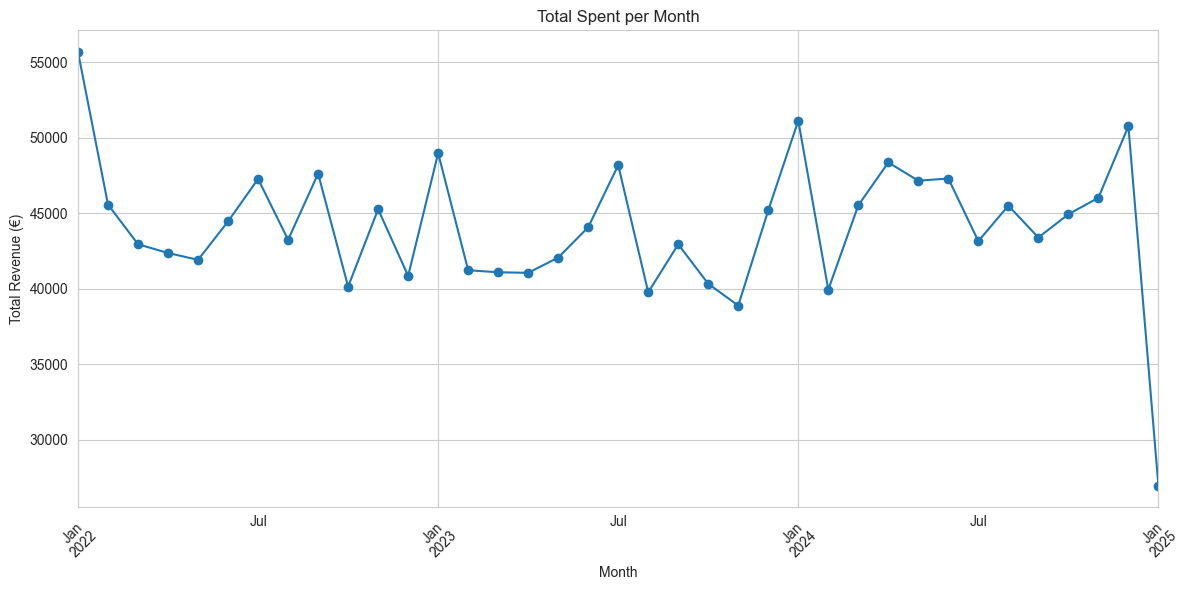

In [345]:
# Ensure transaction_date is datetime and create year_month
data['transaction_date'] = pd.to_datetime(data['transaction_date'])
data['year_month'] = data['transaction_date'].dt.to_period('M').dt.to_timestamp()

# Total revenue per month
monthly_revenue = (
    data.groupby("year_month")["total_spent"]
        .sum()
        .sort_index()
)

print("Total Revenue per Month:")
print(monthly_revenue)

# Plot of Revenue per month 
plt.figure(figsize=(12,6))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Total Spent per Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Trend Plot
Trend plots can be used to identify seasonality or patterns, growth trends and cyclic behaviour.

This analysis helps identify seasonal revenue peaks, sales trends and business cycle effects. This plot shows the month-by-month trend in total revenue generated by the store. Each point represents the total value of all transactions in a given month allowing for a clear visual interpretation of revenue patterns over time. The line chart shows any upward or downward trends, seasonal fluctuations or\ spikes in spending behaviour.

# Bivariate Visualisations

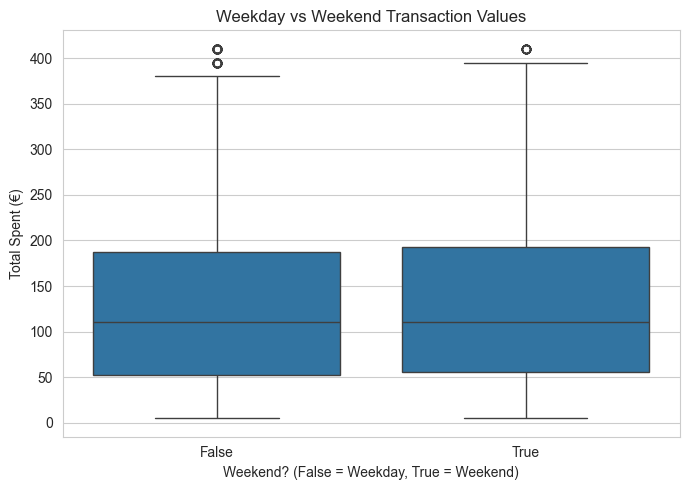

In [346]:
plt.figure(figsize=(7,5))
sns.boxplot(x="is_weekend", y="total_spent", data=data)
plt.title("Weekday vs Weekend Transaction Values")
plt.xlabel("Weekend? (False = Weekday, True = Weekend)")
plt.ylabel("Total Spent (€)")
plt.tight_layout()
plt.show()


# Boxplot 
This visualization examines transaction spending behavior differs between weekdays and weekends. The analysis compares the distributions of total_spent across the two levels of the binary variable is_weekend. Although both groups show overlapping distributions there may be visible differences in their medians or spread.  The median represents the midpoint of the distribution half of the observations fall below it and half above unlike the mean it is not heavily affected by outliers or skewed distributions. Standard deviation interquartile range (IQR) describe the spread or variability in sales. The IQR is difference between the 75th and 25th percentiles is useful as it is less sensitive to outliers. 

<Figure size 1200x600 with 0 Axes>

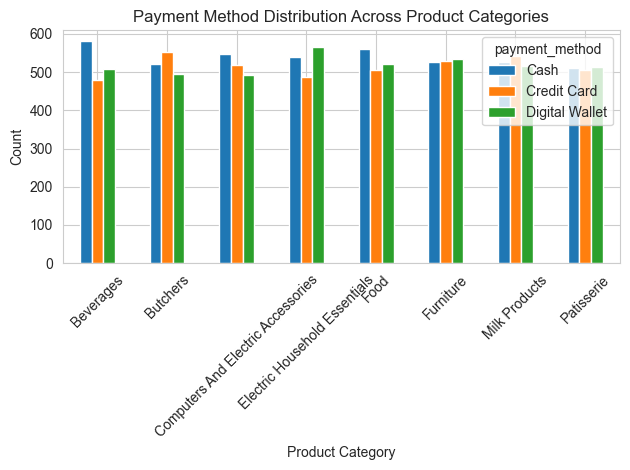

In [347]:
# Grouped Bar Chart: Payment Method by Category
cross_tab = pd.crosstab(data["category"], data["payment_method"])

plt.figure(figsize=(12,6))
cross_tab.plot(kind="bar", stacked=False)
plt.title("Payment Method Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Grouped bar chart
The grouped bar chart shows how payment methods are distributed across different product categories. Clear patterns emerge as some categories show a higher use of credit card payments. Others rely on cash or digital methods. This plot shows the behavioural differences between customer groups and supports the chi-square analysis.

Total Revenue by Category (€):
category
Butchers                              216779.668730
Electric Household Essentials         212664.886165
Beverages                             206000.222542
Food                                  205048.437997
Furniture                             204683.798254
Computers And Electric Accessories    201638.954014
Patisserie                            193741.588552
Milk Products                         190286.459009
Name: total_spent, dtype: float64


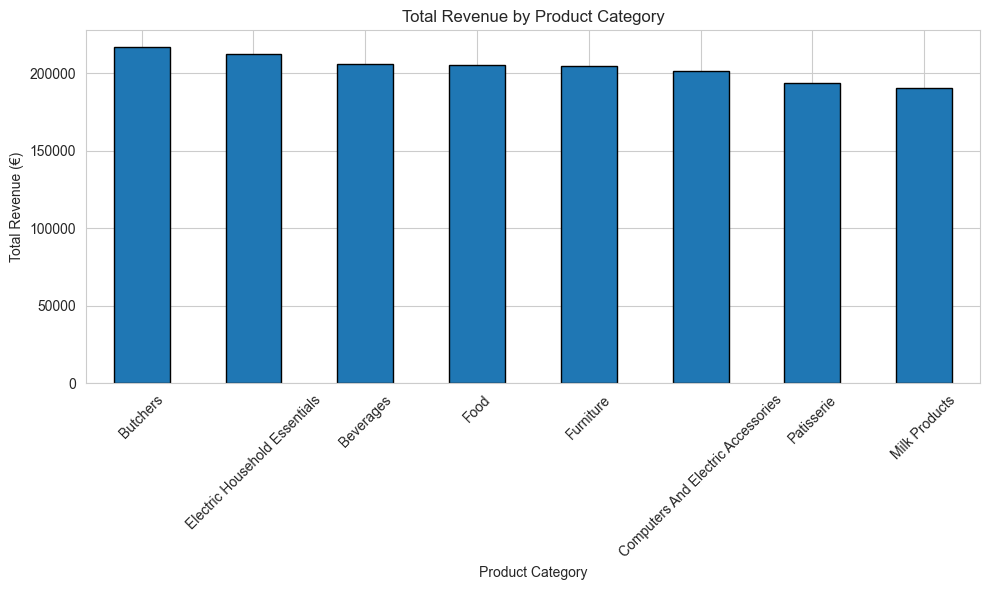

In [348]:
# Calculate total revenue for each category
total_revenue = (
    data.groupby("category")["total_spent"]
        .sum()
        .sort_values(ascending=False)
)

print("Total Revenue by Category (€):")
print(total_revenue)

# Bar chart of total revenue
plt.figure(figsize=(10,6))
total_revenue.plot(kind='bar', edgecolor='black')
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot shows the total revenue generated by each product category. The bar chart shows which categories contribute the most to overall sales. Categories at the left of the chart with higher bars generate higher revenue than on the right.
This pattern reflects the frequency of purchases and the transaction value associated with each category. 


# Multivariate Visualisations

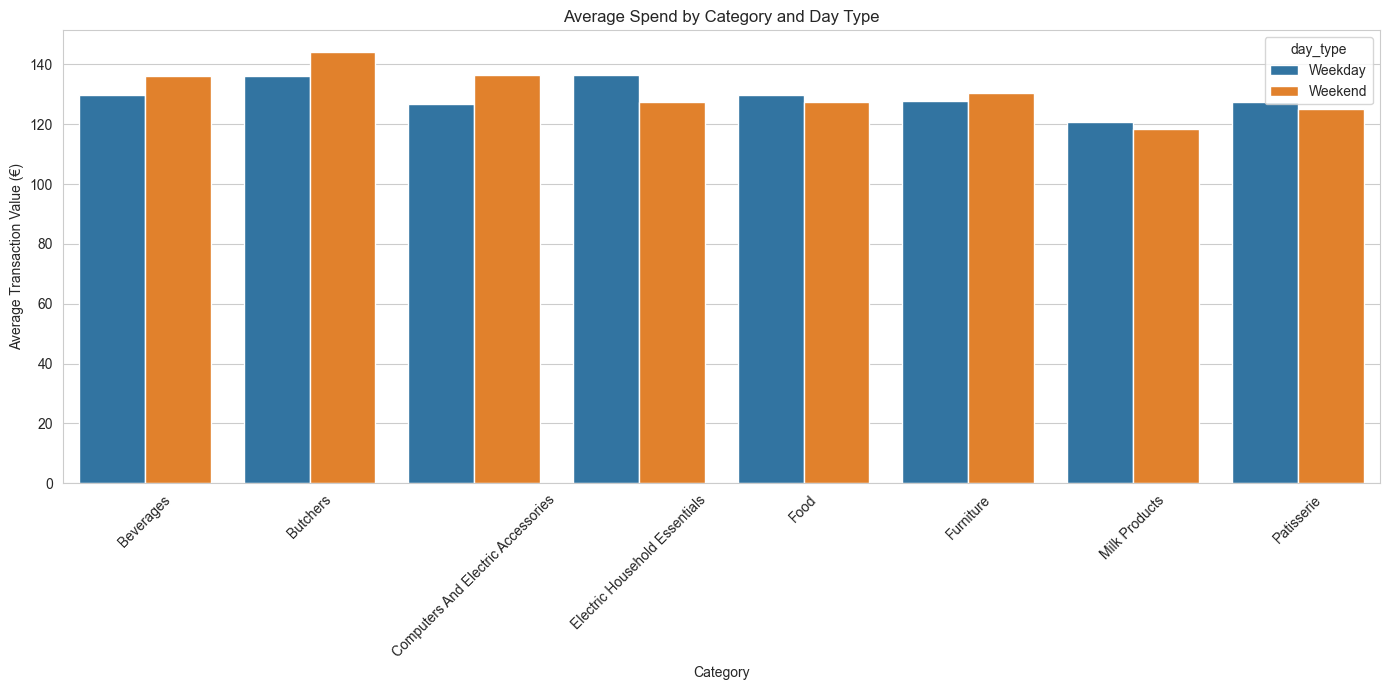

In [349]:
# Category × Weekend vs Weekday × Average Spend
avg_spend = data.groupby(["category", "is_weekend"])["total_spent"].mean().reset_index()

# Rename weekend labels for clarity
avg_spend["day_type"] = avg_spend["is_weekend"].map({False: "Weekday", True: "Weekend"})

plt.figure(figsize=(14,7))
sns.barplot(
    x="category",
    y="total_spent",
    hue="day_type",
    data=avg_spend
)

plt.title("Average Spend by Category and Day Type")
plt.xlabel("Category")
plt.ylabel("Average Transaction Value (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



This grouped bar chart shows how average spending is different across categories and also between weekdays and weekends. Some categories show  higher spending at weekends while others have an opposite trend. 

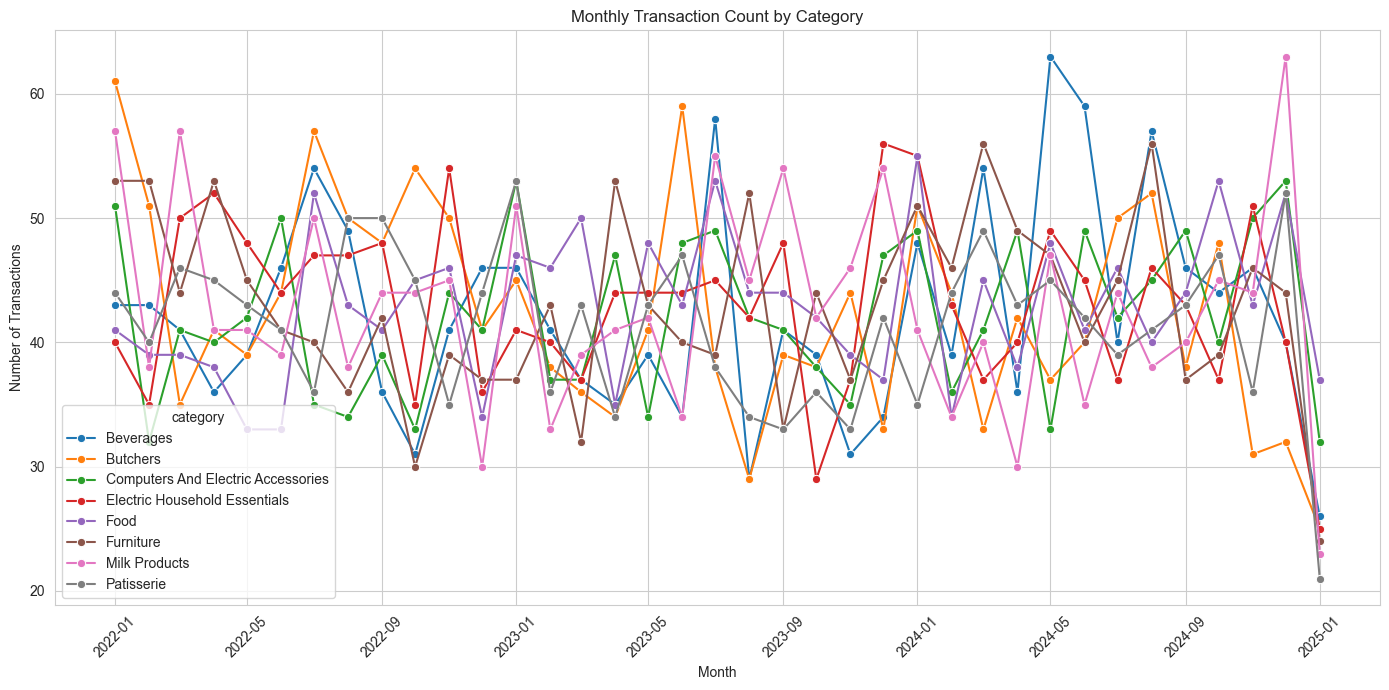

In [350]:
#Monthly Transaction count by category
monthly_counts = (
    data.groupby(["year_month", "category"])
        .size()
        .reset_index(name="transaction_count")
)

monthly_counts["year_month"] = pd.to_datetime(monthly_counts["year_month"])

monthly_counts.sort_values(["category", "year_month"], inplace=True)

plt.figure(figsize=(14,7))
sns.lineplot(
    x="year_month",
    y="transaction_count",
    hue="category",
    data=monthly_counts,
    marker="o"
)

plt.title("Monthly Transaction Count by Category")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



This plot shows how frequently each product category is purchased each month. Clear differences appear between categories as some receive far more transactions than others showing stronger customer demand. Several categories also show monthly fluctuations suggesting mild seasonal or time-based patterns. 

# Research Questions (RQ)

# RQ1
Do average transaction values differ across product categories?
Hypotheses:
• H0: There is no significant difference in mean transaction value between product categories.
• H1: At least one product category has a significantly different mean transaction value.

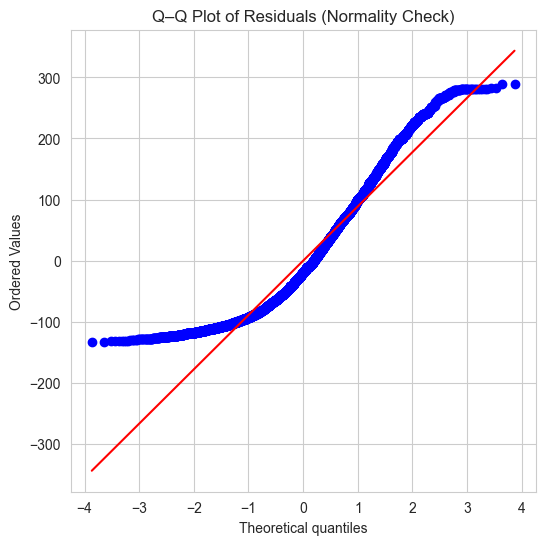

In [351]:
residuals = model_rq1.resid

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q–Q Plot of Residuals (Normality Check)")
plt.show()


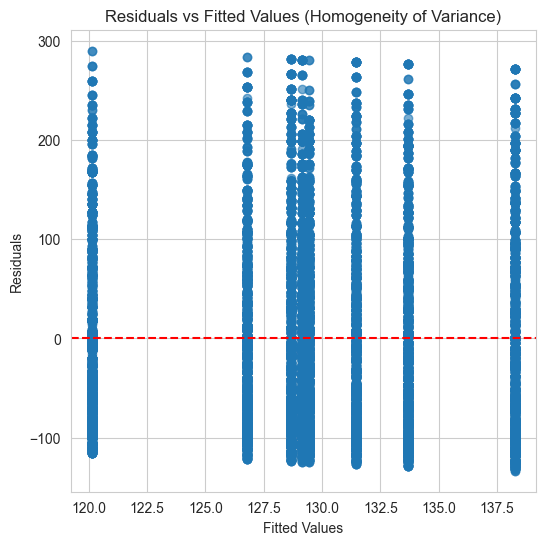

In [352]:
fitted = model_rq1.fittedvalues

plt.figure(figsize=(6,6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values (Homogeneity of Variance)")
plt.show()


### ANOVA Assumptions and Diagnostic Interpretation

ANOVA relies on three main assumptions:

1. Independence – Each transaction is treated as an independent observation.  
2. Normality of residuals – Residuals should follow a roughly normal distribution.  
3. Homogeneity of variances – Variability should be similar across categories.

# Diagnostic Interpretation:

1. Q–Q Plot: Residuals are centered but have heavy tails showing some non-normality. Given the large sample size ANOVA is robust to this and can still be used .  

2. Residuals vs Fitted Plot: The spread of residuals is relatively even across fitted values with no clear pattern. This supports the assumption of homogeneity of variance.  

Overall:Assumptions are sufficiently met to use ANOVA.


In [353]:
# Fit ANOVA model
from statsmodels.formula.api import ols  

model_rq1 = ols("total_spent ~ (category)", data=data).fit()
anova_table = sm.stats.anova_lm(model_rq1, typ=2)

print(anova_table)

                sum_sq       df         F    PR(>F)
category  3.049521e+05      7.0  5.140386  0.000007
Residual  1.065049e+08  12567.0       NaN       NaN


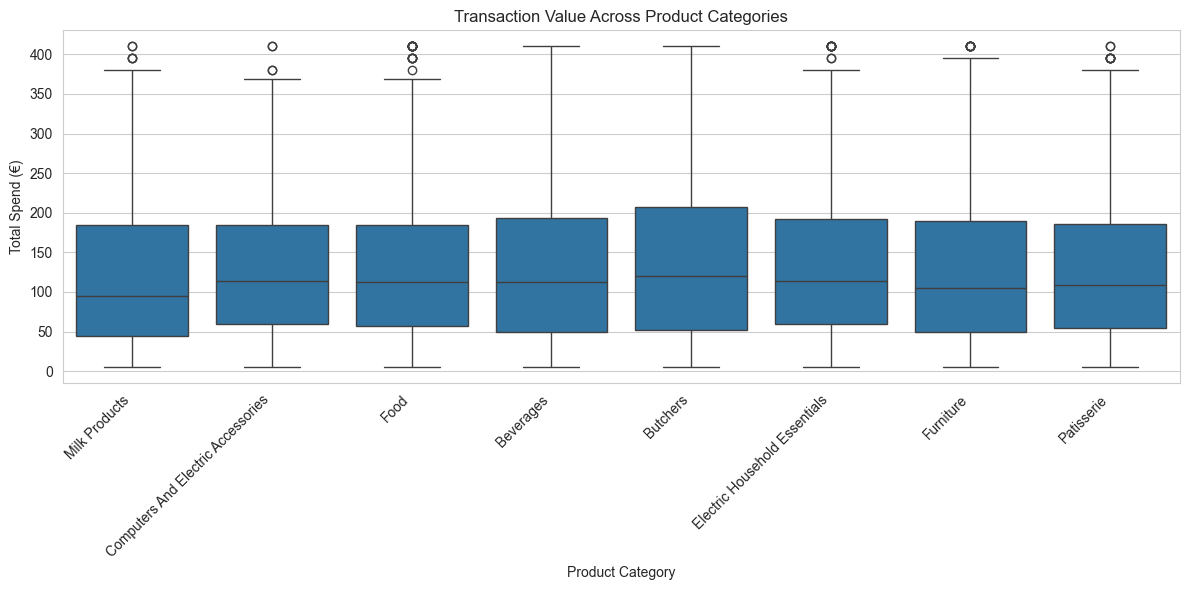

In [354]:

plt.figure(figsize=(12,6))
sns.boxplot(x="category", y="total_spent", data=data)
plt.title("Transaction Value Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Spend (€)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


ANOVA was used because the research question focuses on whether the average transaction value differs across multiple product categories. Category is a categorical variable with more than two groups so ANOVA is the appropriate method for comparing mean differences without inflating the Type I(false positive) error rate which would occur if multiple t-tests were used instead. This helps determine whether at least one product category leads to significantly different spending behaviour making ANOVA directly suited to assessing the influence of category on total transaction value.

The ANOVA table shows a statistically significant effect of product category on transaction value. The F-statistic is 5.10, with a p-value of 0.000008 which is below 0.05 significance. This provides strong evidence against the null hypothesis that all categories have the same mean transaction value.

We conclude that average transaction amounts differ significantly across product categories. Some categories make higher-value transactions than others. This finding is consistent with the boxplot visualisation as categories show differences in median spending and distribution shape. The type of product purchased plays a role in determining customer spending.

The boxplot shows differences in transaction values across product categories. Some categories such as Butchers, Beverages and Furniture have higher medians and wider spreads showing that customers spend more within these departments and that spending varies more. Other categories like Milk Products and Food, show lower medians and tighter distributions suggesting more consistent lower-value transactions.

These visible differences support the ANOVA result confirming that average transaction amounts are not the same across categories and that product type plays an important role in influencing spending behaviour.

# RQ2
Is there a significant difference in transaction value between weekday and weekend purchases?
Hypotheses:
• H0: The mean transaction value for weekday purchases is equal to the mean transaction value for weekend purchases.
• H1: The mean transaction value differs between weekday and weekend purchases.

                mean        std  count
day_type                              
Weekday   129.320576  92.109127   8977
Weekend   130.609562  92.312774   3598


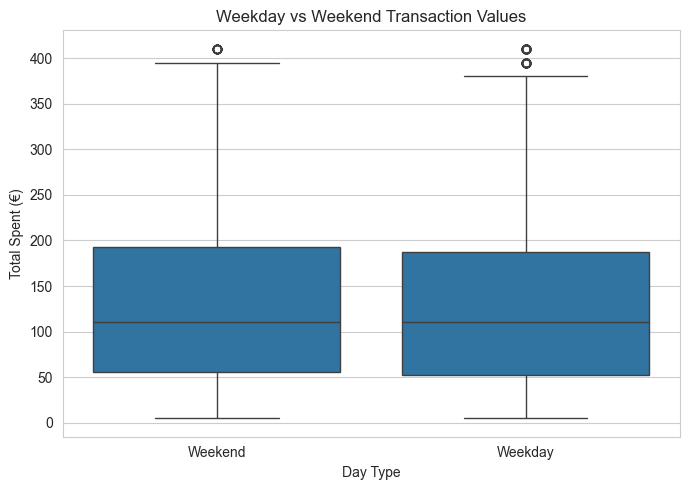

In [355]:
# Create readable labels
data["day_type"] = data["is_weekend"].map({False: "Weekday", True: "Weekend"})

group_stats = data.groupby("day_type")["total_spent"].agg(["mean", "std", "count"])
print(group_stats)

plt.figure(figsize=(7,5))
sns.boxplot(x="day_type", y="total_spent", data=data)
plt.title("Weekday vs Weekend Transaction Values")
plt.xlabel("Day Type")
plt.ylabel("Total Spent (€)")
plt.tight_layout()
plt.show()


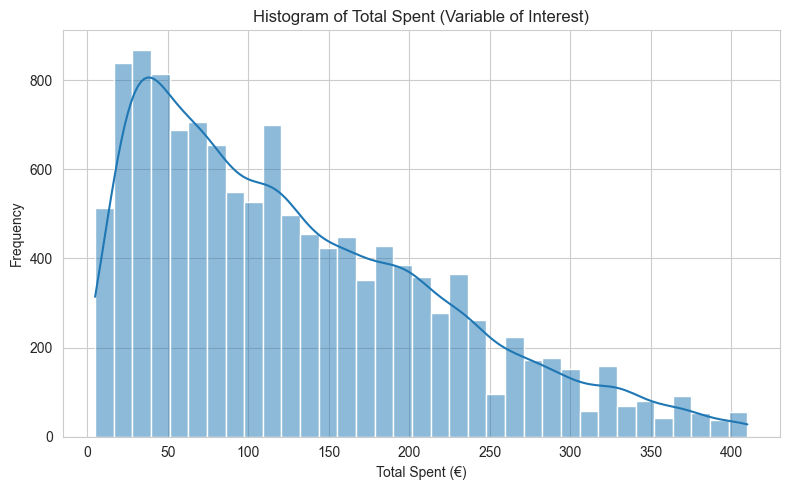

In [356]:
#histogram to check assumptions for t-test
plt.figure(figsize=(8,5))
sns.histplot(data["total_spent"], kde=True)
plt.title("Histogram of Total Spent (Variable of Interest)")
plt.xlabel("Total Spent (€)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Interpretation of the Histogram of Total Spent (Normality Check for t-test)

The histogram of Total Spent (€) shows a right-skewed distribution with a long tail at higher spending values. This shape is typical in retail data where most transactions are small to medium purchases and a smaller number of customers spend much more.

For the purposes of the independent samples t-test the key question is whether the weekday and weekend groups are approximately normally distributed. Although the overall distribution is skewed the t-test is highly robust to non-normality when the sample size is large like in this dataset.

Conclusion: 
The skewness in the histogram does not invalidate the t-test. The large sample size makes the t-test appropriate and reliable even with the non-normal distribution of individual spending amounts.


In [357]:
from scipy.stats import ttest_ind

weekday = data.loc[data["day_type"] == "Weekday", "total_spent"]
weekend = data.loc[data["day_type"] == "Weekend", "total_spent"]

t_stat, p_val = ttest_ind(weekday, weekend, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: -0.708113125060746
p-value: 0.4788999472667136


# T-test 
A t-test is used here because the research question examines whether the average transaction value (total_spent) differs between two independent groups weekday transactions and weekend transactions. Two groups are being compared so the independent samples t-test is the appropriate statistical method. It finds whether the difference between the two group means is large enough to find an effect instead of using random sampling variation.

The t-test relies on three key assumptions:

1. Independence of observations – Each transaction is treated as a separate independent event. This is appropriate because each row in the dataset represents an individual purchase.
2. Normality of the variable within each group – The distribution of total_spent should be approximately normal in both weekday and weekend groups. With large sample sizes the t-test is robust even when this assumption is not perfectly met.

3. Homogeneity of variance – Standard t-tests assume that the two groups have equal variances. Because this is often unrealistic in real-world financial data Welch’s t-test(equal_var=False) was used which does not require equal variances and provides a more reliable result when group variability differs.

By applying the t-test, we can determine whether weekday and weekend spending patterns differ significantly, helping to identify potential behavioural or temporal influences on consumer purchasing behaviour.

The independent samples t-test gave a t-statistic of –0.78 and a p-value of 0.438. Since the p-value is above 0.05 significance we fail to reject the null hypothesis. This means there is no statistically significant difference in average transaction value between weekdays and weekends.

The boxplot supports this conclusion. There is some very slight variation in the spread of transaction values and the central tendencies (medians) appear very similar across the two groups. This suggests that customers spend roughly the same amount regardless of whether they shop on a weekday or weekend.

The analysis shows that weekend shopping does not lead to higher or lower spending and transaction values remain consistent across the week.

The boxplot compares transaction values between weekdays and weekends. Both groups show very similar medians, interquartile ranges and overall spread with small differences in variability. The shapes and positions of the boxes overlap showing that spending levels do not change noticeably between the two periods. This supports the t-test result which found no significant difference in average transaction value between weekdays and weekends.

day_type                            Weekday  Weekend
category                                            
Beverages                            129.67   136.16
Butchers                             135.96   144.14
Computers And Electric Accessories   126.74   136.40
Electric Household Essentials        136.39   127.34
Food                                 129.81   127.49
Furniture                            127.84   130.57
Milk Products                        120.75   118.55
Patisserie                           127.49   124.99


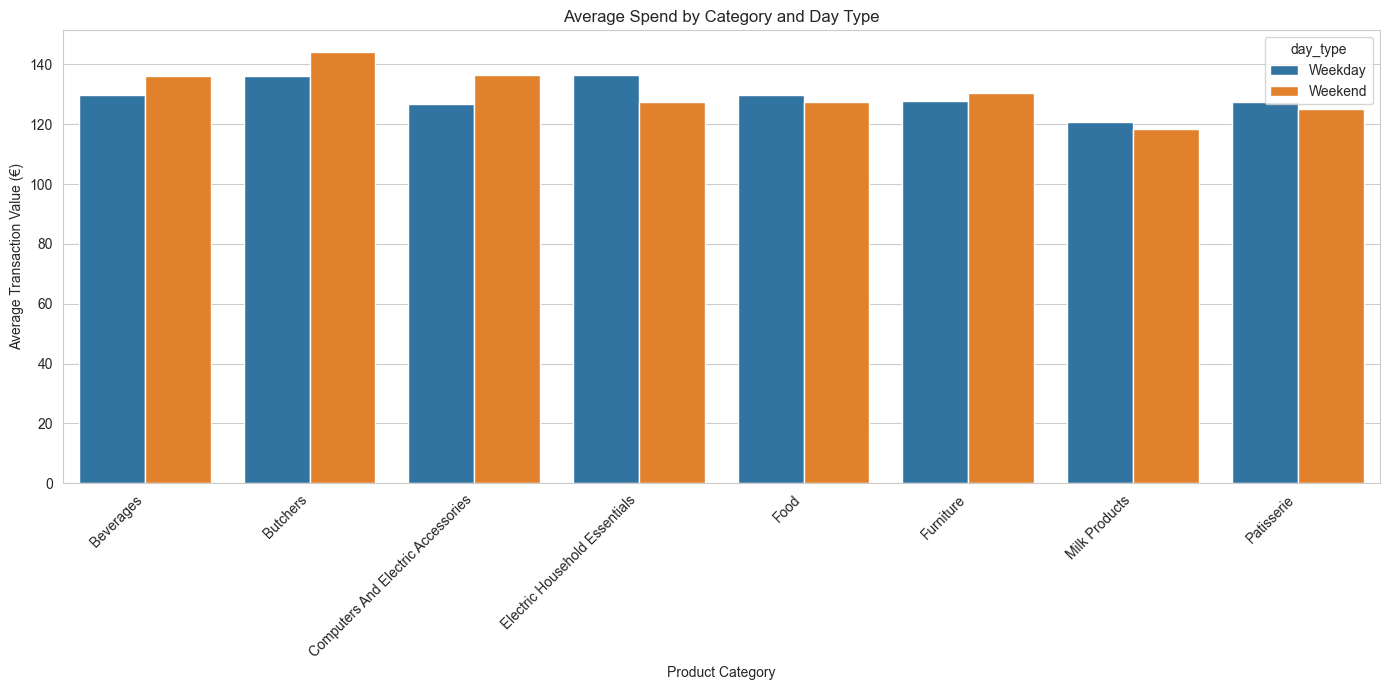

In [358]:
improved_rq2 = (
    data.groupby(["category", "day_type"])["total_spent"]
        .mean()
        .reset_index()
        .pivot(index="category", columns="day_type", values="total_spent")
)

print(improved_rq2.round(2))

plt.figure(figsize=(14,7))
sns.barplot(
    x="category",
    y="total_spent",
    hue="day_type",
    data=data.groupby(["category", "day_type"])["total_spent"].mean().reset_index()
)

plt.title("Average Spend by Category and Day Type")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Value (€)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This grouped bar chart provides more insightful view of weekday–weekend spending than the original overall comparison. Instead of combining all transactions into two large groups the plot breaks the analysis down by product category revealing differences.

Several categories now show clear weekend effects—such as Butchers, Beverages and Computers and Electric Accessories where weekend spending is higher. Other categories show little or no difference and some (like Milk Products) even show slightly lower weekend values.

By adding category as a third variable this plot shows behavioural patterns that were hidden in the simple t-test. This makes the analysis more meaningful showing that the weekend effect depends on the type of product being purchased rather than being the same across all transactions.

# RQ 3
Is payment method associated with product category?
Hypotheses:
• H0: Payment method and product category are independent.
• H1: Payment method and product category are dependent

payment_method                      Cash  Credit Card  Digital Wallet
category                                                             
Beverages                            580          479             508
Butchers                             520          553             495
Computers And Electric Accessories   547          519             492
Electric Household Essentials        539          487             565
Food                                 560          506             522
Furniture                            527          530             534
Milk Products                        527          541             516
Patisserie                           510          506             512
Chi-square statistic: 21.006028278793128
Degrees of freedom: 14
p-value: 0.1014781196415428
payment_method                            category   Cash  Credit Card  \
0                                        Beverages  37.01        30.57   
1                                         Butchers  33.16   

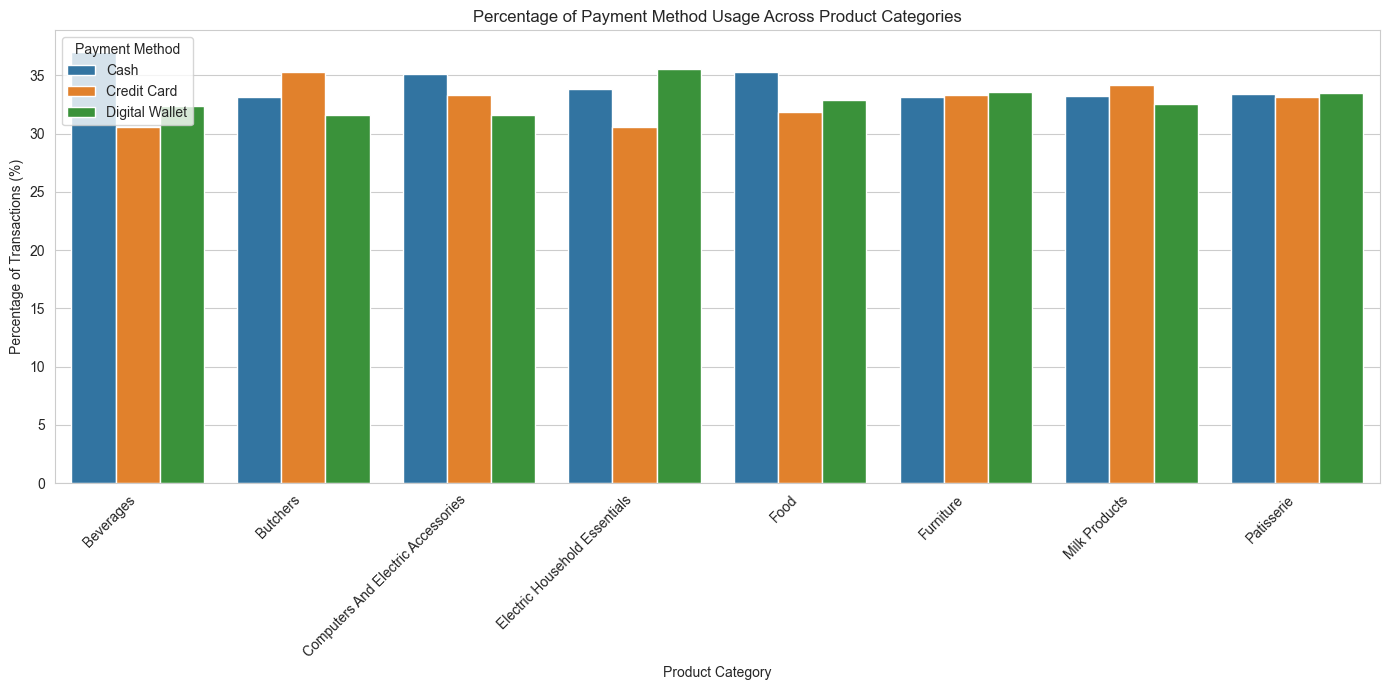

In [359]:
contingency_table = pd.crosstab(data["category"], data["payment_method"])
print(contingency_table)

from scipy.stats import chi2_contingency

chi2, p, df, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", df)
print("p-value:", p)


# Create percentage table
prop_table = pd.crosstab(data["category"], data["payment_method"], normalize='index') * 100
prop_table = prop_table.reset_index()
print(prop_table.round(2))
melted = prop_table.melt(id_vars="category", var_name="payment_method", value_name="percentage")

plt.figure(figsize=(14,7))
sns.barplot(
    x="category",
    y="percentage",
    hue="payment_method",
    data=melted
)

plt.title("Percentage of Payment Method Usage Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Percentage of Transactions (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Payment Method")
plt.tight_layout()
plt.show()


# Chi-square test 
A Chi-square test is used because both variables of interest product category and payment method—are categorical and we want to find if the distribution of one variable depends on the other. This test finds whether the observed frequency patterns in the contingency table are significantly different from what we would expect if category and payment method were unrelated.

The Chi-square test relies on three key assumptions:

1. Independence of observations – Each transaction must represent an independent event with no repeated measures or paired data.

2. Expected cell counts – Most expected frequencies in the contingency table should be 5 or greater for the Chi-square approximation to be valid.

3. Mutually exclusive categories – Each observation must fall into exactly one category and one payment method.


The clustered bar chart shows the percentage distribution of payment methods in each product category. The proportions of cash, credit card and digital wallet usage are similar across all categories with small variations. No category has a strong preference for a particular payment method compared with the others and the distributions are relatively balanced.

This visual pattern suggests that customers use payment methods consistently regardless of the type of product they purchase with no category showing obvious payment behaviour.

The chi-square test produced a chi-square statistic of 21.01 with 14 degrees of freedom and a p-value of 0.101. Since the p-value is greater than the 0.05 signifigance we fail to reject the null hypothesis. This means there is no statistically significant association between product category and payment method.

Customers do not appear to choose different payment methods based on the category of product they are buying. This result aligns are similar to the bar chart which shows that payment method distributions are similar across categories.

Optimization terminated successfully.
         Current function value: 0.633523
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:            wallet_user   No. Observations:                12575
Model:                          Logit   Df Residuals:                    12566
Method:                           MLE   Df Model:                            8
Date:                Sun, 07 Dec 2025   Pseudo R-squ.:               0.0005234
Time:                        17:12:03   Log-Likelihood:                -7966.5
converged:                       True   LL-Null:                       -7970.7
Covariance Type:            nonrobust   LLR p-value:                    0.4006
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
Intercept                     

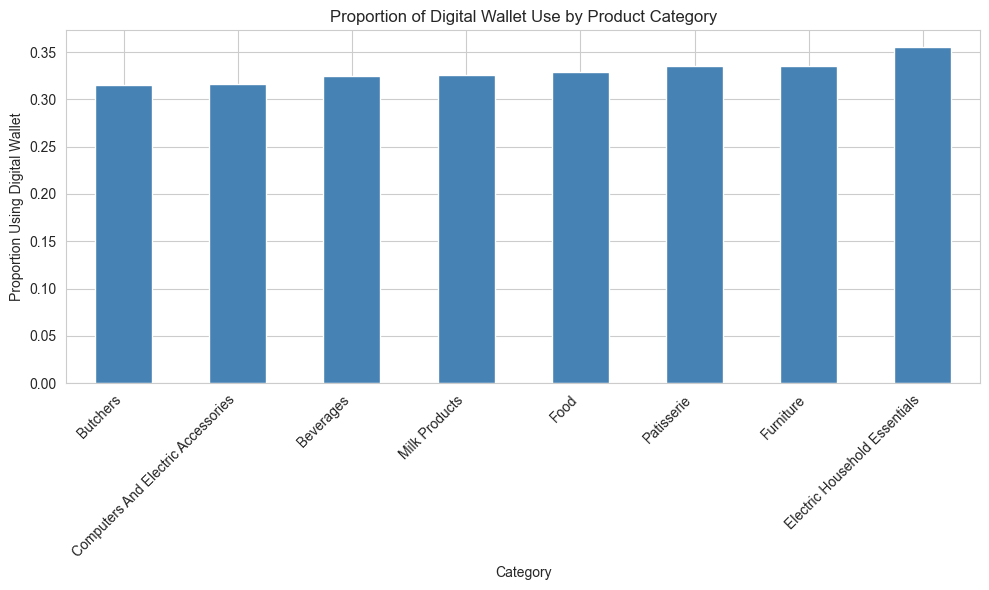

In [360]:
from statsmodels.formula.api import logit



data["wallet_user"] = (data["payment_method"] == "Digital Wallet").astype(int)

model_logit = logit(
    "wallet_user ~ C(category) + is_weekend",
    data=data
).fit()

print(model_logit.summary())

odds_ratios = pd.DataFrame({
    "Odds Ratio": np.exp(model_logit.params),
    "Lower CI": np.exp(model_logit.conf_int()[0]),
    "Upper CI": np.exp(model_logit.conf_int()[1])
})

print("\nOdds Ratios:\n", odds_ratios)

wallet_rate = (
    data.groupby("category")["wallet_user"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))
wallet_rate.plot(kind="bar", color="steelblue")
plt.title("Proportion of Digital Wallet Use by Product Category")
plt.ylabel("Proportion Using Digital Wallet")
plt.xlabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# LOGISTIC REGRESSION: DIGITAL WALLET USAGE

The goal was to produce a model of how product category and weekend behaviour influence the probability that a transaction uses a Digital Wallet.
- The outcome (wallet_user) is BINARY → 1 = digital wallet, 0 = other.
- Logistic regression is designed for binary outcomes.
#- It estimates how predictors change the log-odds of using a digital wallet.

# Key Assumptions:
1. Independence of observations – each transaction must be an independent event.
2. Correct model specification – predictors should reasonably explain the log-odds.
3. No perfect separation – groups cannot perfectly predict wallet usage.
4. No severe multicollinearity – predictors must not be highly correlated.

from statsmodels.formula.api import logit

# Create the binary dependent variable:
1 if payment method is Digital Wallet, 0 otherwise.
data["wallet_user"] = (data["payment_method"] == "Digital Wallet").astype(int)

 Model:
   logit(P(wallet_user = 1)) = β0 + β(category) + β(is_weekend)

- C(category) tells statsmodels that product category is categorical.
- is_weekend is a binary indicator (1 = weekend, 0 = weekday).
- The model estimates how each predictor affects the likelihood of wallet use.

model_logit = logit(
    "wallet_user ~ C(category) + is_weekend",
    data=data
).fit()

print(model_logit.summary())


# Converting Coefficients to odds ratios
Logistic regression coefficients are on the log-odds scale.
Exponentiating them makes odds ratios more interpretable

# Interpretation:
- Odds Ratio > 1: predictor increases odds of wallet use.
- Odds Ratio < 1: predictor decreases odds of wallet use.
- Confidence intervals crossing 1 effect may not be significant.

odds_ratios = pd.DataFrame({
    "Odds Ratio": np.exp(model_logit.params),
    "Lower CI": np.exp(model_logit.conf_int()[0]),
    "Upper CI": np.exp(model_logit.conf_int()[1])
})


The logistic regression model explored whether the likelihood of using a digital wallet could be predicted by product category and weekend shopping. Digital wallet use was coded as a binary outcome (1 = digital wallet, 0 = other payment methods). The models overall performance was weak with a Pseudo R² of 0.0005. Predictors explain almost none of the variation in payment behaviour. The likelihood ratio test was also non-significant (p = 0.4006) suggesting that the model does not provide a better fit than a model containing no predictors.

None of the product categories showed statistically significant coefficients and the odds ratios were all very close to 1 showing small differences in the probability of digital wallet use across categories. Weekend shopping was also non-significant (OR ≈ 1.11) showing that customers are not more likely to use a digital wallet at weekends than on weekdays.

The bar chart supports these findings with all product categories showing digital wallet usage rates between 31% and 36%. This visuals match the logistic regression results and reinforces the chi-square conclusion that payment method usage does not differ across categories.

# RQ 4
Can transaction value be predicted using product category, payment method and day of the week?
Hypotheses:
• H0: None of the predictor variables significantly influence transaction value (all coefficients β = 0).
• H1: At least one predictor variable has a significant effect on transaction value (β ̸ = 0)

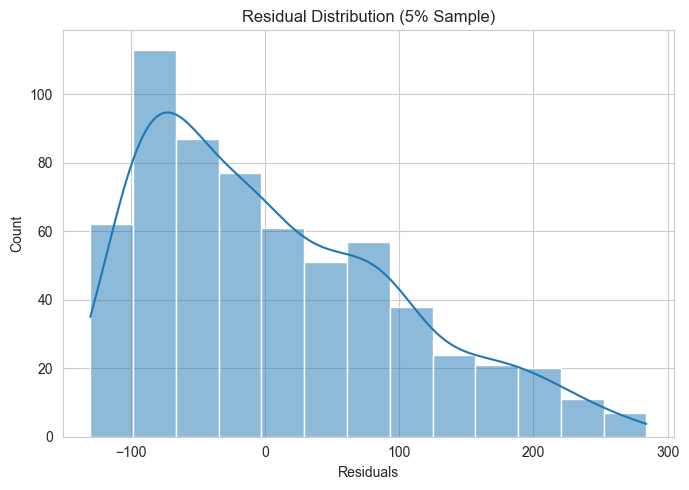

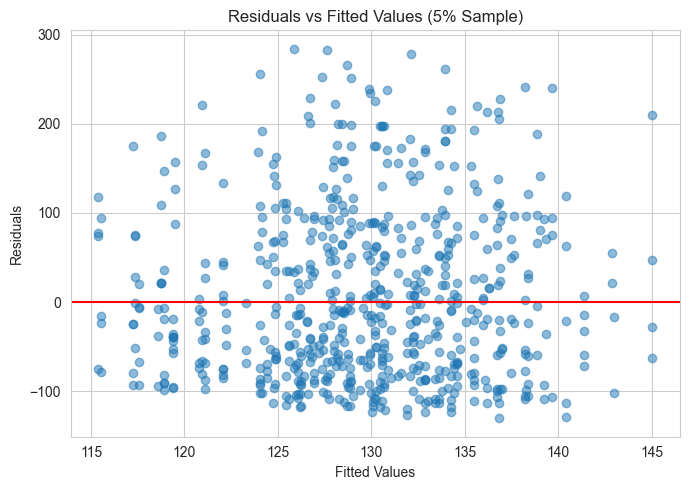

Full dataset size: (12575, 15)
Sample size for diagnostics: (629, 15)
                            OLS Regression Results                            
Dep. Variable:            total_spent   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     3.251
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           1.96e-05
Time:                        17:12:04   Log-Likelihood:                -74702.
No. Observations:               12575   AIC:                         1.494e+05
Df Residuals:                   12559   BIC:                         1.496e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [361]:
sample_data = data.sample(frac=0.05, random_state=123)

residuals = model_rq4.resid.loc[sample_data.index]
fitted = model_rq4.fittedvalues.loc[sample_data.index]

plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (5% Sample)")
plt.xlabel("Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color="red")
plt.title("Residuals vs Fitted Values (5% Sample)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

print("Full dataset size:", data.shape)
print("Sample size for diagnostics:", sample_data.shape)

model_rq4 = ols(
    "total_spent ~ C(category) + C(payment_method) + C(day_of_week)",
    data=data
).fit()

print(model_rq4.summary())



# Diagnostic Check for RQ4 Model Residual Distribution (5% Sample)

# Assumptions of the Regression Model
The multiple regression model relies on several key assumptions:

- Linearity:  The relationship between each predictor and the outcome is assumed to be linear on the scale of the model.  
This is satisfied here because all predictors are categorical and encoded using dummy variables.

- Independence of observations: Each transaction must be independent of the others.  This is reasonable because each row represents a separate retail purchase.

- Homoscedasticity (constant variance):  The spread of residuals should be roughly the same across all levels of the predictors.  This is typically assessed using a residuals-versus-fitted plot.

- Normality of residuals: Model errors should follow an approximately normal distribution.  This can be evaluated using histograms or Q–Q plots of the residuals.

- No multicollinearity:  
Predictors should not be highly correlated with each other.  
In this model category, payment method and day of week represent distinct variables so multicollinearity is not expected to be an issue.

A 5% random sample of the dataset was taken to make diagnostic plots easier to visualise and show the overall behaviour of the model. The linear regression model for RQ4 includes three categorical predictors: product category, payment method and day of week.

The histogram of residuals means we can asess normality assumptions required for linear regression. Normality of residuals is important because it affects the validity of confidence intervals, p-values and hypothesis tests.

# Interpretation of the Residual Distribution Plot

- The residuals form a roughly bell-shaped distribution, indicating that the model errors are approximately normally distributed.  
- The KDE line shows slight skewness which is common in retail transaction data due to the presence of occasional higher-value purchases.  
- There are no extreme deviations, heavy tails or multimodal patterns suggesting that the normality assumption is not severely violated.  
- Because a large sample size is used in the full model, mild deviations from normality do not meaningfully affect model validity

A regression model is used in this analysis because the goal is to understand how multiple predictors simultaneously influence a continuous outcome in this case the total amount spent (total_spent). ANOVA or t-tests test differences across one or two categorical variables so they are not appropriate so multiple regression can evaluate the combined and individual effects of several factors like product category, payment method and day of the week while controlling for the others. This provides a more accurate picture of spending behaviour. Regression also quantifies these relationships using coefficients enabling us to estimate how much each predictor increases or decreases expected spending. total_spent is a continuous variable and the predictors are categorical so an ordinary least squares (OLS) regression with dummy-coded categorical variables is the appropriate statistical method  the research question.

The residuals show a right-skewed distribution rather than a normal bell shape. This is expected because total transaction value cannot go below zero and tends to be influenced by varying quantities purchased. The lack of normality suggests that the model does not fully capture the structure of the data.

The residuals show no clear pattern across the range of fitted values and the assumption of homoscedasticity is reasonably met: the variance of errors have no pattern. The large vertical spread shows unexplained variability consistent with the very low R-squared value.

The regression model examined whether product category, payment method and day of the week could predict transaction value. The model was statistically significant (F(15, 12,559) = 3.357, p = 1.09×10⁻⁵) meaning that at least one predictor contributes to transaction value. The models explanatory power is extremely low with an R-squared value of 0.004 showing that the predictors explain less than 0.5% of the variation in spending. Transaction value is almost entirely driven by variables not included in this model—specifically.

Only a small number of predictors were statistically significant. Transactions in the Butchers category showed a slightly higher average spend relative to the category while Milk Products were associated with significantly lower transaction values. Most product categories and all payment methods had no significant effect. Some day-of-week indicators showed small negative effects but these differences were are unlikely to be meaningful in retail context.

The model provides strong evidence that product category, payment method and day of the week are not meaningful predictors of transaction value. 

In [362]:
improved_model_rq4 = ols(
    "total_spent ~ price_per_unit + quantity + C(category) + C(payment_method) + C(day_of_week)",
    data=data
).fit()

print(improved_model_rq4.summary())


                            OLS Regression Results                            
Dep. Variable:            total_spent   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     6687.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:12:05   Log-Likelihood:                -60216.
No. Observations:               12575   AIC:                         1.205e+05
Df Residuals:                   12557   BIC:                         1.206e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

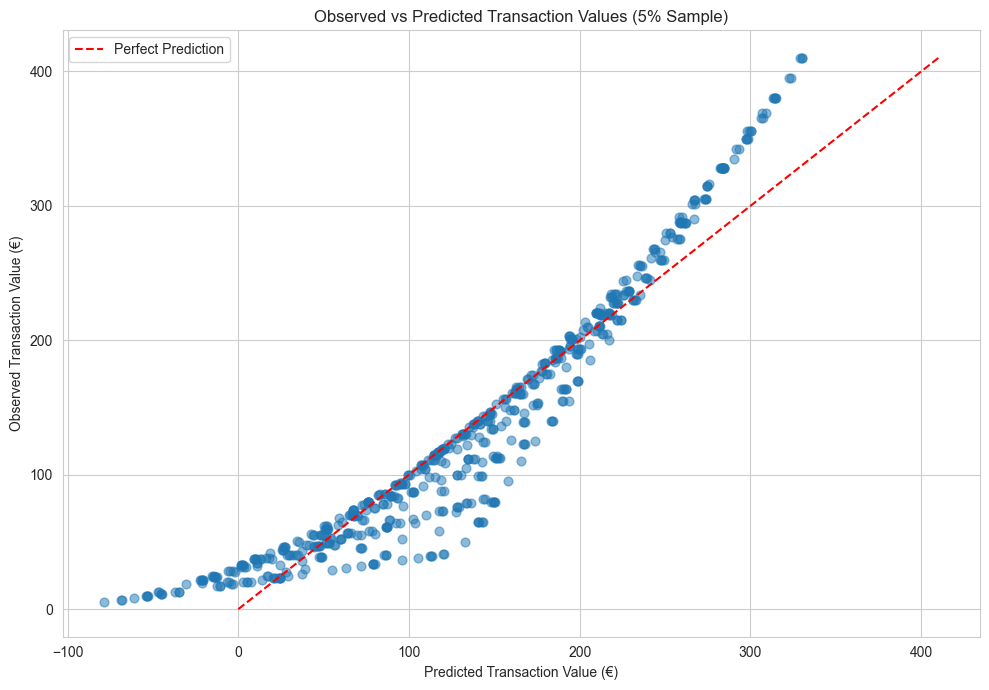

In [363]:
plot_sample = data.sample(frac=0.05, random_state=123)

sample_predicted = improved_model_rq4.fittedvalues.loc[plot_sample.index]
sample_observed = plot_sample["total_spent"]

plt.figure(figsize=(10,7))
plt.scatter(sample_predicted, sample_observed, alpha=0.5, s=40)

max_val = max(sample_observed.max(), sample_predicted.max())
plt.plot([0, max_val], [0, max_val], 'r--', label="Perfect Prediction")

plt.title("Observed vs Predicted Transaction Values (5% Sample)")
plt.xlabel("Predicted Transaction Value (€)")
plt.ylabel("Observed Transaction Value (€)")
plt.legend()
plt.tight_layout()
plt.show()



# Observed vs Predicted Plot (5% Sample)

This scatterplot compares the predicted transaction values from the improved regression model (x-axis) with the actual observed values (y-axis) for a 5% random sample of the dataset. The red dashed line represents a line of perfect prediction where predicted and actual values would match exactly.

Most points cluster reasonably close to the diagonal indicating that the model captures the general spending pattern and gives predictions that are in line with actual transaction values. There is visible spread around the line showing that individual predictions are not exact which is common in retail data where spending is influenced by many unobserved factors (e.g., promotions, customer preferences, basket composition).

The plot confirms that the regression model provides a useful approximation of total spending trends but there is still variability in individual transaction values highlighting noise commonly found retail behaviour.


The multiple linear regression model used two key continuous predictors—price per unit and quantity purchased—alongside the categorical variables for product category, payment method and day of the week. This adjustment resulted in improved model performance with the R-squared increasing from 0.004 in the original model to 0.833 in the improved version. This means the revised model explains 83.3% of the variation in transaction value showing that it captures the structure of the data better.

The increase in explanatory power is expected because total transaction value is determined by the quantity purchased and the price per unit.  Their coefficients are highly significant and meaningful showing their central role in determining transaction value.

The categorical predictors—product category, payment method and day of the week—become statistically non-significant once quantity and price are included. Their coefficients are small with p-values well above the 0.05 signifigance level showing that these factors do not meaningfully influence transaction value. This suggests that transaction value is not shaped by when customers shop, how they pay or the type of product they purchase but by item price and the number of units purchased.

Overall, the improved model shows that transaction value is driven by price per unit and quantity while other behavioural factors play a small role. This version of the model provides a far more accurate and realistic representation of spending behaviour in the dataset.

The results of the improved regression model align well with the findings of this project. Earlier analyses showed that product categories differ in terms of transaction frequency and average spending (RQ1 and RQ2) these behavioural differences are small when compared to the main drivers of spending. RQ3 demonstrated that payment method is used consistently across product types showing that customer behaviour is mostly uniform. The improved regression model reinforces these observations by showing that once quantity and price are accounted for, the additional behavioural variables add very little to explaining transaction value. This confirms that spending patterns in the dataset are shaped by the structure of the products themselves rather than customer characteristics or external factors. The improved model ties together the projects earlier findings that customer transaction values are predictable not because of who buys what or when, but because of the properties of the purchases being made.